In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("product_sales_dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Product_ID       1000 non-null   int64
 1   Product_Name     1000 non-null   str  
 2   Category         1000 non-null   str  
 3   Price_USD        1000 non-null   int64
 4   Quantity_Sold    1000 non-null   int64
 5   Total_Sales_USD  1000 non-null   int64
 6   Order_Date       1000 non-null   str  
 7   Customer_City    1000 non-null   str  
dtypes: int64(4), str(4)
memory usage: 62.6 KB


In [4]:
df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [5]:
df['Customer_City'].unique()

<StringArray>
['Karachi', 'Peshawar', 'Lahore', 'Quetta', 'Islamabad']
Length: 5, dtype: str

In [6]:
df.describe()

,Product_ID,Price_USD,Quantity_Sold,Total_Sales_USD
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,253.757000,5.455000,1371.032000
std,288.819436,144.902362,2.964247,1156.021422
min,1001.000000,10.000000,1.000000,10.000000
25%,1250.750000,126.750000,3.000000,425.750000
50%,1500.500000,255.000000,5.000000,1040.000000
75%,1750.250000,383.250000,8.000000,2006.250000
max,2000.000000,500.000000,10.000000,5000.000000


In [7]:
print(df.shape)

(1000, 8)


In [8]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Quantity_Sold',
       'Total_Sales_USD', 'Order_Date', 'Customer_City'],
      dtype='str')

In [9]:
print(df.isnull().sum())

Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(df['Order_Date'])

0     2025-01-24
1     2026-04-01
2     2025-11-05
3     2026-01-05
4     2025-11-28
         ...    
995   2025-11-25
996   2026-05-09
997   2026-03-27
998   2026-05-01
999   2025-11-30
Name: Order_Date, Length: 1000, dtype: datetime64[us]


In [13]:
df['month']=df['Order_Date'].dt.month
print(df['month'])

0       1
1       4
2      11
3       1
4      11
       ..
995    11
996     5
997     3
998     5
999    11
Name: month, Length: 1000, dtype: int32


In [14]:
df['Year'] = df['Order_Date'].dt.year
print(df['Year'])

0      2025
1      2026
2      2025
3      2026
4      2025
       ... 
995    2025
996    2026
997    2026
998    2026
999    2025
Name: Year, Length: 1000, dtype: int32


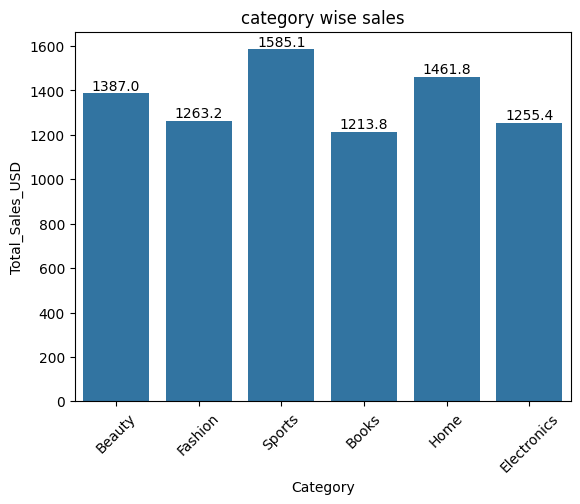

In [15]:
plt.Figure(figsize=(10,4))
b=sns.barplot(df,x='Category',y='Total_Sales_USD',estimator='mean',errorbar=None)
plt.title("category wise sales")
for i in b.containers:
    b.bar_label(i,fmt='%.1f')
plt.xticks(rotation=45)
plt.show()


**obervation**

Different product categories generate different sales amounts. Some categories have higher average sales than others.

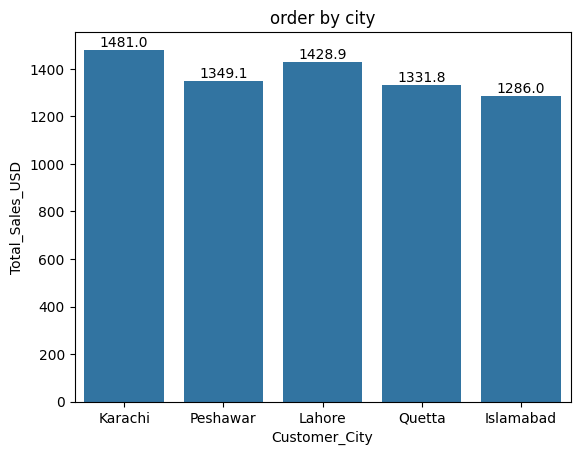

In [16]:
plt.Figure(figsize=(10,4))
b=sns.barplot(df,x='Customer_City',y='Total_Sales_USD',estimator='mean',errorbar=None)
plt.title("order by city")
for i in b.containers:
    b.bar_label(i,fmt='%.1f')

**observation**

Sales/orders evary from city to city. Certain cities contribute more revenue.

Text(0.5, 1.0, 'Sales Distribution')

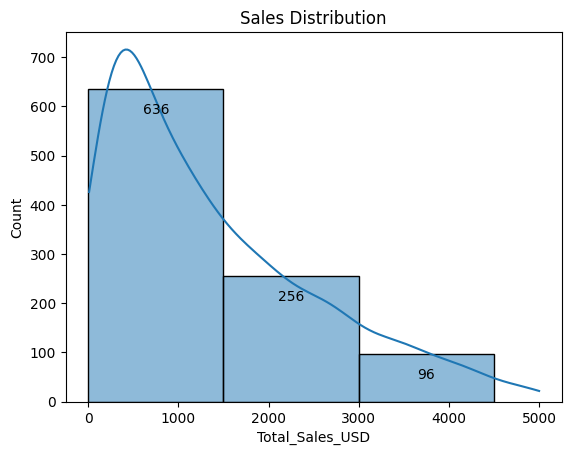

In [17]:
plt.Figure(figsize=(10,4))
x = sns.histplot(df['Total_Sales_USD'], kde=True, bins=list(range(0, 6000, 1500)))
x.bar_label(x.containers[0], padding=-20)
plt.title("Sales Distribution")

**Observation**

Most sales are concentrated in a particular range, while very high sales occur less frequently.

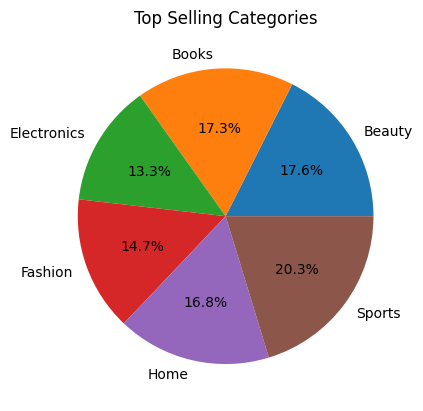

In [18]:
top_cat = df.groupby('Category')['Quantity_Sold'].sum()
top_cat.plot(kind='pie',autopct='%1.1f%%')
plt.title("Top Selling Categories")
plt.xlabel("")
plt.show()

**Observation**

The pie chart shows which product category has the highest share in total quantity sold

In [19]:
print(df.columns)

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Quantity_Sold',
       'Total_Sales_USD', 'Order_Date', 'Customer_City', 'month', 'Year'],
      dtype='str')


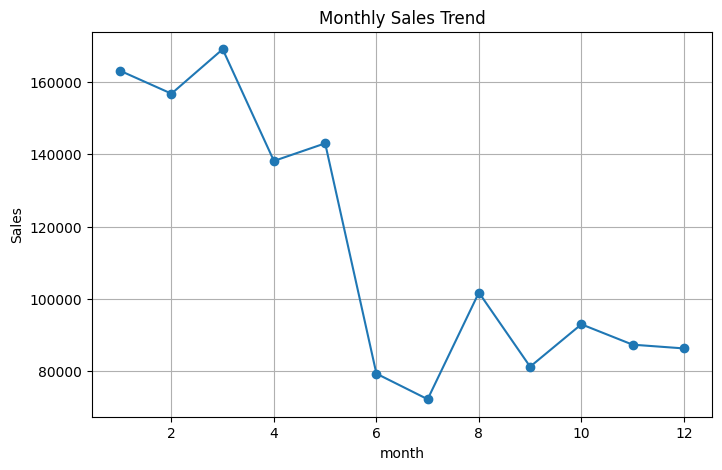

In [20]:
monthly_sales = df.groupby('month')['Total_Sales_USD'].sum()
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("Sales")

plt.grid()
plt.show()

**Observation**

Sales change month by month. Some months show increased sales growth.

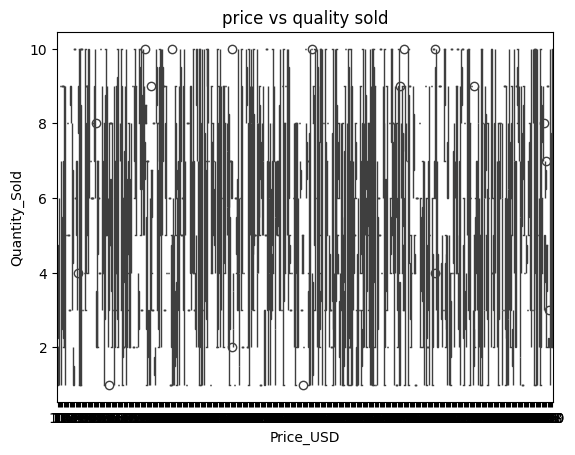

In [21]:
plt.Figure(figsize=(8,5))
sns.boxplot(df,x='Price_USD',y='Quantity_Sold')

plt.title("price vs quality sold")
plt.show()

**Observation**

Helps compare customer purchasing behavior across categories.

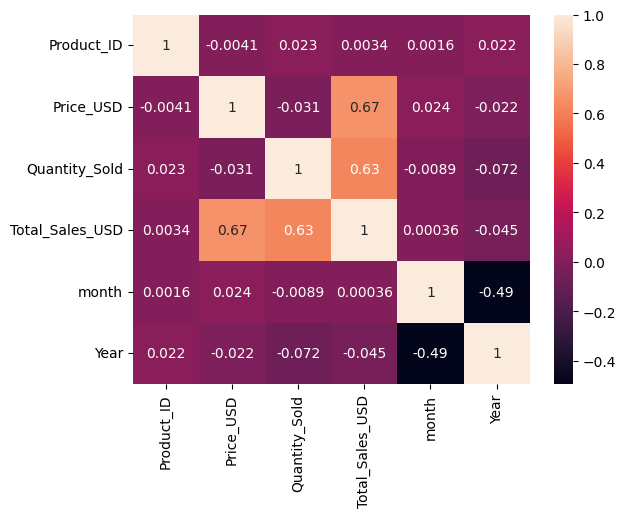

In [22]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()

**Observation**

The charts together help understand sales performance, customer trends, and business growth patterns.

### Conclusion


1. The project helps in understanding sales and customer trends using data visualization.

2. Different charts and diagrams make the dataset easy to analyze and interpret.

3. The analysis shows that some product categories and cities generate higher sales.

4. Monthly sales trends help identify business growth and performance patterns.

5. Overall, the project provides useful insights for better business decision-making and future improvements.
